# バックテスト doe-003

BAND_VWAP と DD_PROFIT, DD_RATIO の依存性調査

In [1]:
import os
import sys

path_up = os.path.join("..", "..")
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import glob
from os.path import expanduser

import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

from funcs.tse import get_ticker_name_list

## 基本情報

In [3]:
# 実験名
name_doe = "doe-003"
param_1 = "BAND_VWAP"
param_2 = "DD_PROFIT"
param_3 = "DD_RATIO"

# 銘柄コード
code: str = "9984"
name = get_ticker_name_list([code])[code]
print(name)

# 実験表の読み込み
path_csv = os.path.join("..", f"{name_doe}.csv")
df_doe = pd.read_csv(path_csv)[[param_1, param_2, param_3]]
print(df_doe)

ソフトバンクグループ
     BAND_VWAP  DD_PROFIT  DD_RATIO
0            3         10       0.1
1            3         10       0.2
2            3         10       0.3
3            3         10       0.4
4            3         10       0.5
..         ...        ...       ...
184          7         70       0.5
185          7         70       0.6
186          7         70       0.7
187          7         70       0.8
188          7         70       0.9

[189 rows x 3 columns]


## すべての結果を読み込む

In [4]:
path_backtest = os.path.join(expanduser("~"), "MyProjects", "backtest", name_doe)

# 結果の CSV ファイル一覧を抽出してソード
dir_search = os.path.join(path_backtest, f"{code}/*/{code}_result.csv")
list_file: list[str] = sorted(glob.glob(dir_search))

# ファイルをひとつひとつ読み込んでリストに保持
list_df: list[pd.DataFrame] = []
for file in list_file:
    list_df.append(pd.read_csv(file))
# 縦に連結してインデックスを振り直す
df = pd.concat(list_df, axis=0).reset_index(drop=True)
# 年月日の date 列を datetime 型に変換
df["date"] = pd.to_datetime(df["date"])
df.columns

Index(['date', 'run', 'PERIOD_WARMUP', 'BAND_VWAP', 'PERIOD_MA_1',
       'PERIOD_RSI', 'PERIOD_MOM', 'DD_PROFIT', 'DD_RATIO', 'LOSSCUT_1',
       'N_MINUS_MAX', 'trade', 'total'],
      dtype='str')

## 集計

In [5]:
# ユニークな実験 run 数
list_run = sorted(list(set(df["run"])))
# run 毎の集計
list_ser_total: list[pd.Series] = []  # 日別収益
list_ser_cumsum: list[pd.Series] = []  # 累積収益
list_median: list[float] = []  # 収益のメジアン
list_iqr: list[float] = []  # 収益のIQR
list_max: list[float] = []  # 収益の最大
list_min: list[float] = []  # 収益の最小
for run in list_run:
    # 指定した run の対象の列を抽出して "date" 列でソード
    df_run = (
        df[df["run"] == run][["date", "total"]]
        .reset_index(drop=True)
        .sort_values("date")
        .set_index("date")
    )
    # 日別収益
    ser_total = df_run["total"]
    ser_total.name = run
    list_ser_total.append(ser_total)

    # 累積収益
    ser_cumsum = df_run["total"].cumsum()
    ser_cumsum.name = run
    list_ser_cumsum.append(ser_cumsum)

    # メジアン
    v_med = df_run["total"].median()
    list_median.append(v_med)

    # 1. 第1四分位数(Q1)と第3四分位数(Q3)を計算
    v_q1 = df_run["total"].quantile(0.25)
    v_q3 = df_run["total"].quantile(0.75)
    # 2. IQRを計算
    list_iqr.append(v_q3 - v_q1)

    # 最大
    v_max = df_run["total"].max()
    list_max.append(v_max)

    # 最小
    v_min = df_run["total"].min()
    list_min.append(v_min)

In [6]:
print("\n# Daily Total")
df_total = pd.concat(list_ser_total, axis=1)
print(df_total.tail())

print("\n# Cumulative Total")
df_cumsum = pd.concat(list_ser_cumsum, axis=1)
print(df_cumsum.tail())

print("\n# Madian in the period")
ser_median = pd.Series(list_median, name="median")
print(ser_median)

print("\n# IQR in the period")
ser_iqr = pd.Series(list_median, name="iqr")
print(ser_iqr)

print("\n# Max in the period")
ser_max = pd.Series(list_max, name="max")
print(ser_max)

print("\n# Min in the period")
ser_min = pd.Series(list_min, name="min")
print(ser_min)


# Daily Total
               0       1       2       3       4       5       6       7    \
date                                                                         
2026-03-18  4300.0  4200.0  4100.0  3900.0  3900.0  4800.0  4400.0  3900.0   
2026-03-19 -2700.0 -2700.0 -2700.0 -2900.0 -3000.0 -3300.0 -3300.0 -3400.0   
2026-03-23 -1400.0 -1400.0 -1400.0 -1400.0 -1400.0 -1400.0 -1400.0 -1400.0   
2026-03-24  1300.0  1300.0  1100.0  1200.0  1000.0  5900.0  5900.0  5900.0   
2026-03-25     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

               8       9    ...      179     180      181     182     183  \
date                        ...                                             
2026-03-18  3700.0  5200.0  ...   4600.0  4600.0   4600.0  4600.0  4600.0   
2026-03-19 -3600.0 -4700.0  ...  -3800.0 -3800.0  -3800.0 -3800.0 -3800.0   
2026-03-23 -1400.0 -1400.0  ...   1800.0  1800.0   1800.0  1800.0  1800.0   
2026-03-24  5900.0  2600.0  ...   6300.0  8000.0   96

### チャートのサブタイトルとランキング (Top 5)

In [7]:
# 累積収益の最下行（最新日）の収益でランキング
df_cumsum_latest = df_cumsum.tail(1)
dt_latest = df_cumsum_latest.index[0]
subtitle=f"{name_doe}: {param_1} vs. {param_2}, {param_3} on {dt_latest.date()}"
print(subtitle)

# Top
ser_ranking = df_cumsum_latest.T[dt_latest].sort_values(ascending=False)
list_tops = list(ser_ranking.head(5).index)
print(list_tops)

doe-003: BAND_VWAP vs. DD_PROFIT, DD_RATIO on 2026-03-25
[159, 158, 179, 178, 167]


In [8]:
ser_cumtotal = df_cumsum_latest.T[dt_latest]
ser_cumtotal.name = "cumtotal"
ser_cumtotal

0      -2600.0
1       -200.0
2       1100.0
3        100.0
4      -4100.0
        ...   
184    25700.0
185    60200.0
186    58800.0
187    68000.0
188    68700.0
Name: cumtotal, Length: 189, dtype: float64

## 累積収益トレンド

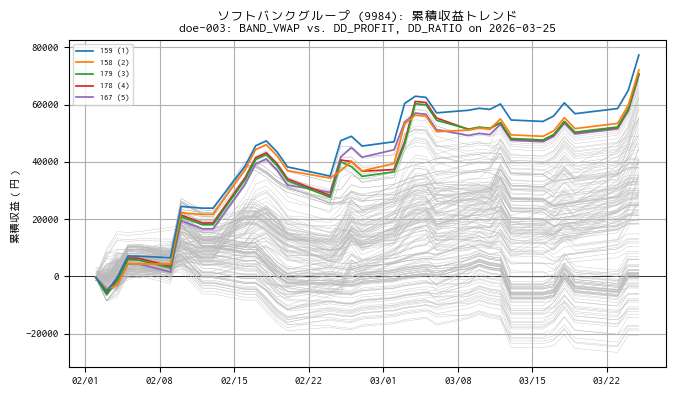

In [9]:
FONT_PATH = "../../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(6.8, 4))

ax.set_title(f"{name} ({code}): 累積収益トレンド\n{subtitle}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.set_ylabel("累積収益（円）")

for colname in list_tops:
    ser = df_cumsum[colname]
    d = list_tops.index(colname)
    ax.plot(ser, linewidth=1.25, zorder=50 - d, label=f"{colname:02d} ({d+1})")

for colname in df_cumsum.columns:
    ser = df_cumsum[colname]
    if colname not in list_tops:
        ax.plot(ser, color="#bbb", linewidth=0.25, zorder=5)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend(fontsize=6)
ax.grid()
plt.tight_layout()
name_img = f"{dt_latest.date()}_{code}_cumsum.png"
plt.savefig(name_img)
plt.show()

## 日毎の収益

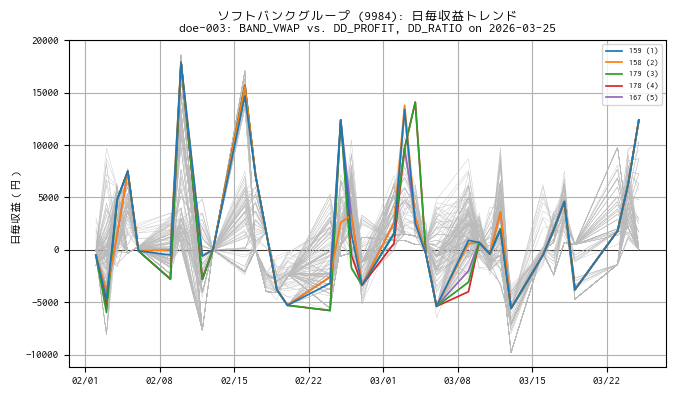

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 4))

ax.set_title(f"{name} ({code}): 日毎収益トレンド\n{subtitle}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.set_ylabel("日毎収益（円）")

for colname in list_tops:
    ser = df_total[colname]
    d = list_tops.index(colname)
    ax.plot(ser, linewidth=1.25, zorder=50 - d, label=f"{colname:02d} ({d+1})")

for colname in df_cumsum.columns:
    ser = df_total[colname]
    if colname not in list_tops:
        ax.plot(ser, color="#bbb", linewidth=0.25, zorder=5)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend(fontsize=6)
ax.grid()
plt.tight_layout()
name_img = f"{dt_latest.date()}_{code}_total.png"
plt.savefig(name_img)
plt.show()

In [11]:
df_summary = pd.DataFrame(
    {
        "BAND_VWAP": df_doe["BAND_VWAP"],
        "DD_PROFIT": df_doe["DD_PROFIT"],
        "DD_RATIO": df_doe["DD_RATIO"],
        "CumSum": ser_cumtotal,
        "Median": ser_median,
        "IQR": ser_iqr,
        "Max": ser_max,
        "Min": ser_min,
    }
)

(
    df_summary.style.set_table_attributes('class="simple"')
    .set_properties(**{"text-align": "right"})
    .format(precision=1, thousands=",")
    .to_html(f"{dt_latest.date()}_{code}_summary.html", index=False)
)

df_summary

,BAND_VWAP,DD_PROFIT,DD_RATIO,CumSum,Median,IQR,Max,Min
0,3,10,0.1,-2600.0,0.0,0.0,4500.0,-7700.0
1,3,10,0.2,-200.0,0.0,0.0,6200.0,-7700.0
2,3,10,0.3,1100.0,0.0,0.0,8300.0,-7700.0
3,3,10,0.4,100.0,0.0,0.0,8100.0,-7700.0
4,3,10,0.5,-4100.0,0.0,0.0,6700.0,-7700.0
...,...,...,...,...,...,...,...,...
184,7,70,0.5,25700.0,700.0,700.0,12400.0,-8100.0
185,7,70,0.6,60200.0,700.0,700.0,17900.0,-8100.0
186,7,70,0.7,58800.0,500.0,500.0,17900.0,-8100.0
187,7,70,0.8,68000.0,0.0,0.0,17900.0,-8100.0


In [12]:
row_best = list_tops[0]
df_summary_best = df_summary.iloc[row_best : row_best + 1]
(
    df_summary_best.style.set_table_attributes('class="simple"')
    .set_properties(**{"text-align": "right"})
    .format(precision=1, thousands=",")
    .to_html(f"{dt_latest.date()}_{code}_summary_best.html", index=False)
)
df_summary_best

,BAND_VWAP,DD_PROFIT,DD_RATIO,CumSum,Median,IQR,Max,Min
159,7,40,0.7,77300.0,900.0,900.0,17900.0,-5600.0
